In [1]:
import sys
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched
# from (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# --- project plotting style (same 4-colour palette as the other notebooks) ------
STYLE = {
    "colors": ["#B80C09", "#D4AF37", "#6E8B3D", "#345995"],
    "figsize": (12, 7),
    "figsize_wide": (14, 7),
    "title_fs": 15,
    "label_fs": 12,
    "tick_fs": 10,
    "annot_fs": 9,
    "legend_fs": 10,
    "dpi": 300,
    "edgecolor": "grey",
    "save": False,             # set True to write PDFs to fig/academic_impact/
    "savedir": "fig/academic_impact",
}
from utils.shared_style import apply_style, extended_palette, savefig, use_style
use_style(STYLE)
apply_style()

In [12]:
# =============================================================================
# ANALYSIS PARAMETERS  --  edit these
# =============================================================================
# The year UK Biobank publications begin in earnest (2013 has only a handful).
# Every "before vs after" split below hinges on this line.
UKBB_YEAR = 2014

# How many of UK Biobank's OWN top fields to follow through the whole database.
TOP_N = 8

# Fields-of-Research level to compare on:
#   "L4" = fine field  (e.g. 4202 Epidemiology)
#   "L2" = broad division (e.g. 42 Health Sciences)
LEVEL = "L4"

# Counting metric:
#   "n_papers" = a paper counts once in EVERY field it carries (absolute; a
#                multi-field paper is double-counted across fields)
#   "n_frac"   = its weight split evenly across its fields (per-level fractional)
# See src/utils/academic_impact_field_counts.py for the exact semantics.
WEIGHT = "n_papers"

# Analysis window. 2025-26 are dropped on purpose: the Dimensions index is still
# filling in for those years (2025 lands at ~40% of 2024, 2026 far less), so their
# counts are not comparable and would fake a collapse. Raise YEAR_MAX once the
# index has caught up.
YEAR_MIN = 2004
YEAR_MAX = 2025

BEFORE_WIN = (YEAR_MIN, UKBB_YEAR - 1)   # marginal-growth window before UK Biobank
AFTER_WIN  = (UKBB_YEAR, YEAR_MAX)       # marginal-growth window after

# Where the count job wrote its partials (counts.ukbb / counts.background).
COUNTS_DIR = P.ACADEMIC_IMPACT / "for_counts_out"

print(f"level={LEVEL}  weight={WEIGHT}  top-N={TOP_N}  UKBB year={UKBB_YEAR}")
print(f"window {YEAR_MIN}-{YEAR_MAX}   before={BEFORE_WIN}  after={AFTER_WIN}")

level=L4  weight=n_papers  top-N=8  UKBB year=2014
window 2004-2025   before=(2004, 2013)  after=(2014, 2025)


In [13]:
# =============================================================================
# LOAD THE TWO ARMS AND BUILD THE "WHOLE DATABASE"
# =============================================================================
# The count job stored two partials:
#   counts.ukbb        = UK Biobank papers only
#   counts.background  = the rest of Dimensions, with UK Biobank papers EXCLUDED
# so the whole database is simply their sum. We collapse the `type` split
# (article / preprint / ...) and keep only the analysis window.
VALUE = WEIGHT

def _load_arm(name):
    d = pd.read_parquet(COUNTS_DIR / f"counts.{name}.parquet")
    d = d[(d.level == LEVEL) & d.year.between(YEAR_MIN, YEAR_MAX)]
    return d.groupby(["year", "code", "for_label"], as_index=False)[["n_papers", "n_frac"]].sum()

ukbb = _load_arm("ukbb")
background = _load_arm("background")
whole = (pd.concat([ukbb, background])
         .groupby(["year", "code", "for_label"], as_index=False)[["n_papers", "n_frac"]].sum())

# UK Biobank's own top fields, ranked over the after-window where it has mass.
_rank = (ukbb[ukbb.year >= UKBB_YEAR]
         .groupby(["code", "for_label"])[VALUE].sum()
         .sort_values(ascending=False).head(TOP_N))
TOP_CODES = [code for code, _ in _rank.index]
TOP_LABELS = [lab for _, lab in _rank.index]

# One fixed colour per field, reused in every chart: colour follows the field,
# never its rank within a given plot.
FIELD_COLORS = dict(zip(TOP_LABELS, extended_palette(TOP_N)))

def _pivot(frame, value):
    return (frame[frame.code.isin(TOP_CODES)]
            .pivot_table(index="year", columns="for_label", values=value, aggfunc="sum")
            .reindex(columns=TOP_LABELS))

whole_ts = _pivot(whole, VALUE)                     # whole-database counts, year x field
ukbb_ts  = _pivot(ukbb,  VALUE)                     # UK Biobank counts,     year x field
share_ts = (ukbb_ts / whole_ts * 100).clip(lower=0) # UK Biobank % of the field

print(f"UK Biobank top {TOP_N} {LEVEL} fields (by {VALUE}, {UKBB_YEAR}+):\n")
for lab in TOP_LABELS:
    tot = int(ukbb[ukbb.for_label == lab][VALUE].sum())
    print(f"  {lab:45s} UKBB total {tot:>7,}   share@{YEAR_MAX} {share_ts.loc[YEAR_MAX, lab]:5.2f}%")

UK Biobank top 8 L4 fields (by n_papers, 2014+):

  Epidemiology                                  UKBB total   6,279   share@2025 14.01%
  Clinical Sciences                             UKBB total   5,467   share@2025  0.61%
  Genetics                                      UKBB total   5,328   share@2025  4.00%
  Biological Psychology                         UKBB total   2,245   share@2025  1.87%
  Cardiovascular Medicine and Haematology       UKBB total   1,906   share@2025  1.40%
  Public Health                                 UKBB total   1,880   share@2025  1.37%
  Oncology and Carcinogenesis                   UKBB total   1,360   share@2025  0.52%
  Health Services and Systems                   UKBB total   1,213   share@2025  0.42%


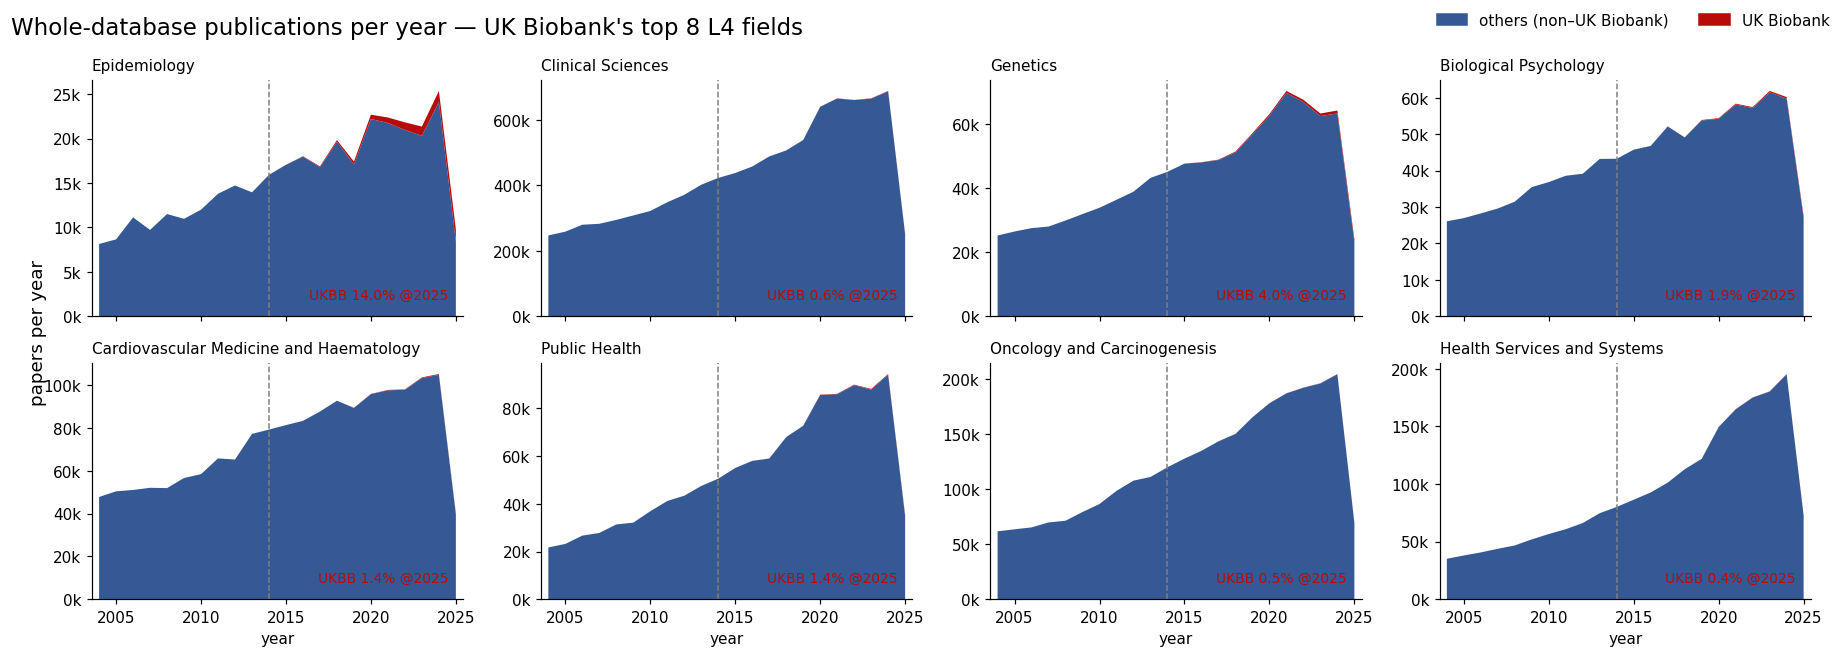

In [14]:
# =============================================================================
# CHART 1 — whole-database growth in UK Biobank's top fields: UKBB vs others
# =============================================================================
# Small multiples, one panel per field. Each panel stacks the field's yearly
# papers into "UK Biobank" vs "everyone else", so you read BOTH the overall trend
# (top of the stack = the whole database) and UK Biobank's slice within it. That
# slice is small in absolute terms, so each panel is annotated with UK Biobank's
# share in the final year. The dashed line marks the first UK Biobank year — a
# time reference, not a claimed cause.
from matplotlib.patches import Patch

C_UKBB = STYLE["colors"][0]     # red  = UK Biobank
C_REST = STYLE["colors"][3]     # blue = everyone else
kfmt = mticker.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k")   # 25371 -> "25k"

ncol = 4
nrow = int(np.ceil(TOP_N / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.0 * nrow), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, lab in zip(axes, TOP_LABELS):
    yrs = whole_ts.index.values
    ukb = ukbb_ts[lab].reindex(whole_ts.index).fillna(0.0).values
    rest = whole_ts[lab].values - ukb
    ax.stackplot(yrs, rest, ukb, colors=[C_REST, C_UKBB])
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_title(lab, fontsize=STYLE["annot_fs"] + 1, loc="left")
    ax.yaxis.set_major_formatter(kfmt)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.set_ylim(bottom=0)
    ax.margins(x=0.02)
    ax.annotate(f"UKBB {share_ts.loc[YEAR_MAX, lab]:.1f}% @{YEAR_MAX}",
                xy=(0.96, 0.06), xycoords="axes fraction", ha="right", va="bottom",
                fontsize=STYLE["annot_fs"], color=C_UKBB)
for ax in axes[TOP_N:]:
    ax.set_visible(False)
for ax in axes[TOP_N - ncol:TOP_N]:      # x-label only on the bottom row that exists
    ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

fig.legend(handles=[Patch(color=C_REST, label="others (non–UK Biobank)"),
                    Patch(color=C_UKBB, label="UK Biobank")],
           loc="upper right", ncol=2, frameon=False, fontsize=STYLE["legend_fs"])
fig.suptitle(f"Whole-database publications per year — UK Biobank's top {TOP_N} "
             f"{LEVEL} fields", fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.supylabel("papers per year", fontsize=STYLE["label_fs"])
fig.tight_layout()
savefig(fig, "01_whole_db_field_trends")
plt.show()

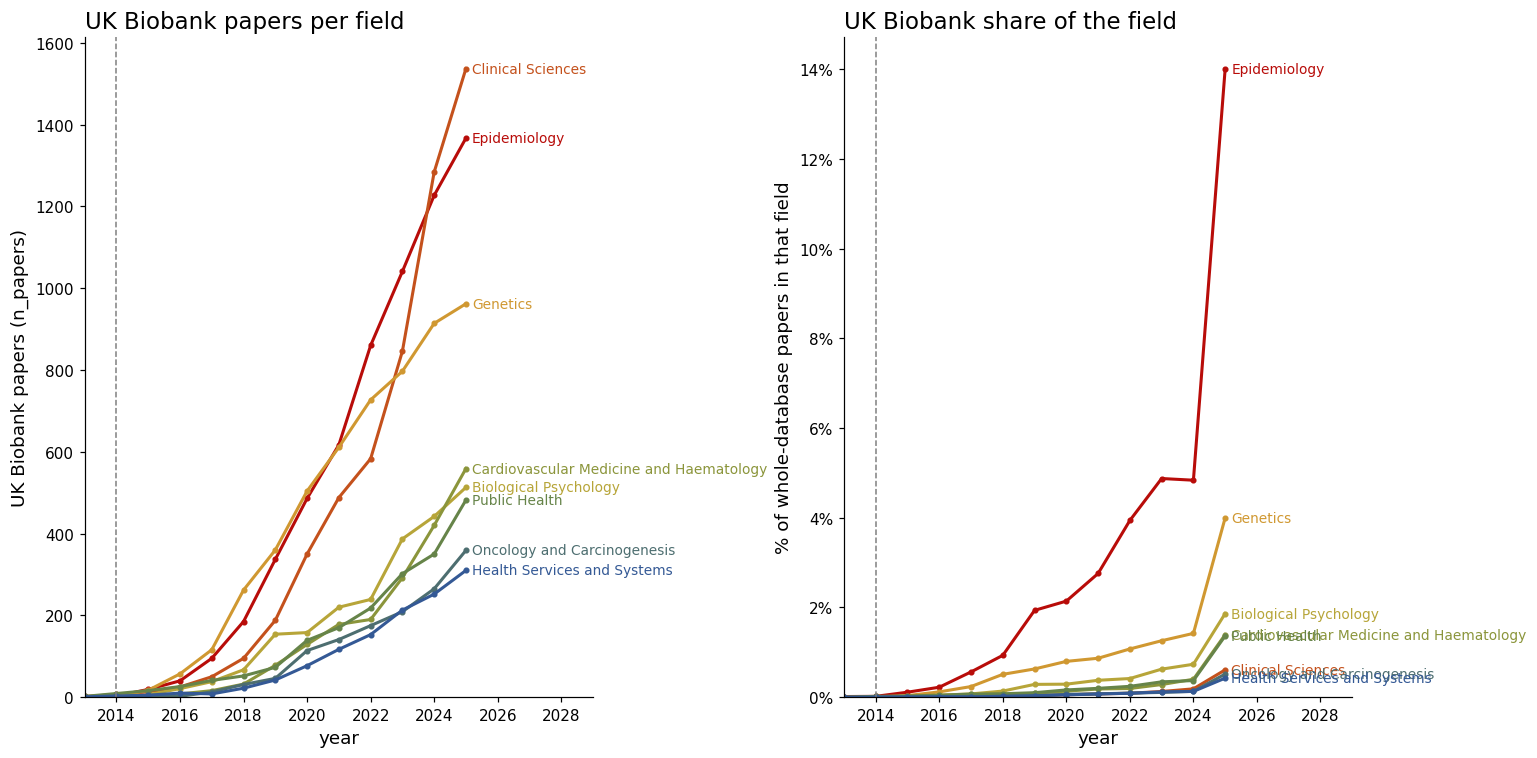

In [15]:
# =============================================================================
# CHART 2 — how much UK Biobank adds, since it started publishing
# =============================================================================
# Left  : UK Biobank's own output in each field (absolute count).
# Right : that output as a SHARE of the whole database in the same field.
# UK Biobank is a small slice of a vast literature, so the share is the truer
# measure of its footprint than the raw count. Fields are direct-labelled on both
# panels; colour follows the field across the whole notebook.
fig, (axL, axR) = plt.subplots(1, 2, figsize=STYLE["figsize_wide"])

for lab in TOP_LABELS:
    col = FIELD_COLORS[lab]
    axL.plot(ukbb_ts.index, ukbb_ts[lab], color=col, lw=2, marker="o", ms=3)
    axR.plot(share_ts.index, share_ts[lab], color=col, lw=2, marker="o", ms=3)
    yl = ukbb_ts[lab].dropna()
    if len(yl):
        axL.annotate(lab, (yl.index[-1], yl.iloc[-1]), color=col,
                     fontsize=STYLE["annot_fs"], va="center",
                     xytext=(4, 0), textcoords="offset points")
    yr = share_ts[lab].dropna()
    if len(yr):
        axR.annotate(lab, (yr.index[-1], yr.iloc[-1]), color=col,
                     fontsize=STYLE["annot_fs"], va="center",
                     xytext=(4, 0), textcoords="offset points")

for ax in (axL, axR):
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_xlabel("year")
    ax.set_ylim(bottom=0)
    ax.set_xlim(UKBB_YEAR - 1, YEAR_MAX + 4)       # room for the direct labels
axL.set_title("UK Biobank papers per field", loc="left", fontsize=STYLE["title_fs"])
axL.set_ylabel(f"UK Biobank papers ({VALUE})")
axR.set_title("UK Biobank share of the field", loc="left", fontsize=STYLE["title_fs"])
axR.set_ylabel("% of whole-database papers in that field")
axR.yaxis.set_major_formatter(mticker.StrMethodFormatter("{x:.0f}%"))
fig.tight_layout()
savefig(fig, "02_ukbb_contribution_{}".format(WEIGHT))
plt.show()

In [16]:
# =============================================================================
# MARGINAL ANNUAL INCREASE SPEED — before vs after UK Biobank
# =============================================================================
# "Marginal speed" = the slope (papers ADDED per year) of a straight-line fit to
# the yearly counts, measured separately in the before- and after-windows. We fit
# it on the WHOLE database (the secular trend) and, for context, on UK Biobank's
# own output.
#
# CAUTION: UK Biobank is far too small (single-digit % of any field) to bend the
# whole-database slope, so the acceleration below is a field-wide trend, NOT
# something UK Biobank caused. The ukbb_after column shows UK Biobank's own pace.
def slope(frame, code, win, value=VALUE):
    y0, y1 = win
    s = (frame[(frame.code == code) & frame.year.between(y0, y1)]
         .groupby("year")[value].sum()
         .reindex(range(y0, y1 + 1)).fillna(0.0))
    if (s > 0).sum() < 2:
        return np.nan
    return float(np.polyfit(s.index.values.astype(float), s.values, 1)[0])

rows = []
for code, lab in zip(TOP_CODES, TOP_LABELS):
    wb = slope(whole, code, BEFORE_WIN)
    wa = slope(whole, code, AFTER_WIN)
    accel = wa / wb if (not np.isnan(wb) and not np.isnan(wa) and wb > 0) else np.nan
    rows.append({
        "field": lab,
        "whole_before_/yr": wb,
        "whole_after_/yr": wa,
        "acceleration_x": accel,
        "ukbb_after_/yr": slope(ukbb, code, AFTER_WIN),
        f"ukbb_share@{YEAR_MAX}_%": share_ts.loc[YEAR_MAX, lab],
    })

speed = pd.DataFrame(rows).set_index("field")
speed_fmt = speed.copy()
for c in ["whole_before_/yr", "whole_after_/yr", "ukbb_after_/yr"]:
    speed_fmt[c] = speed_fmt[c].round(0).astype("Int64")
speed_fmt["acceleration_x"] = speed_fmt["acceleration_x"].round(2)
speed_fmt[f"ukbb_share@{YEAR_MAX}_%"] = speed_fmt[f"ukbb_share@{YEAR_MAX}_%"].round(2)
speed_fmt

,whole_before_/yr,whole_after_/yr,acceleration_x,ukbb_after_/yr,ukbb_share@2025_%
field,,,,,
Epidemiology,694,238,0.34,133,14.01
Clinical Sciences,16127,11500,0.71,133,0.61
Genetics,1899,632,0.33,98,4.00
Biological Psychology,1922,411,0.21,48,1.87
Cardiovascular Medicine and Haematology,2826,-2,-0.00,46,1.40
Public Health,2875,2168,0.75,40,1.37
Oncology and Carcinogenesis,5920,3269,0.55,31,0.52
Health Services and Systems,4228,7240,1.71,28,0.42


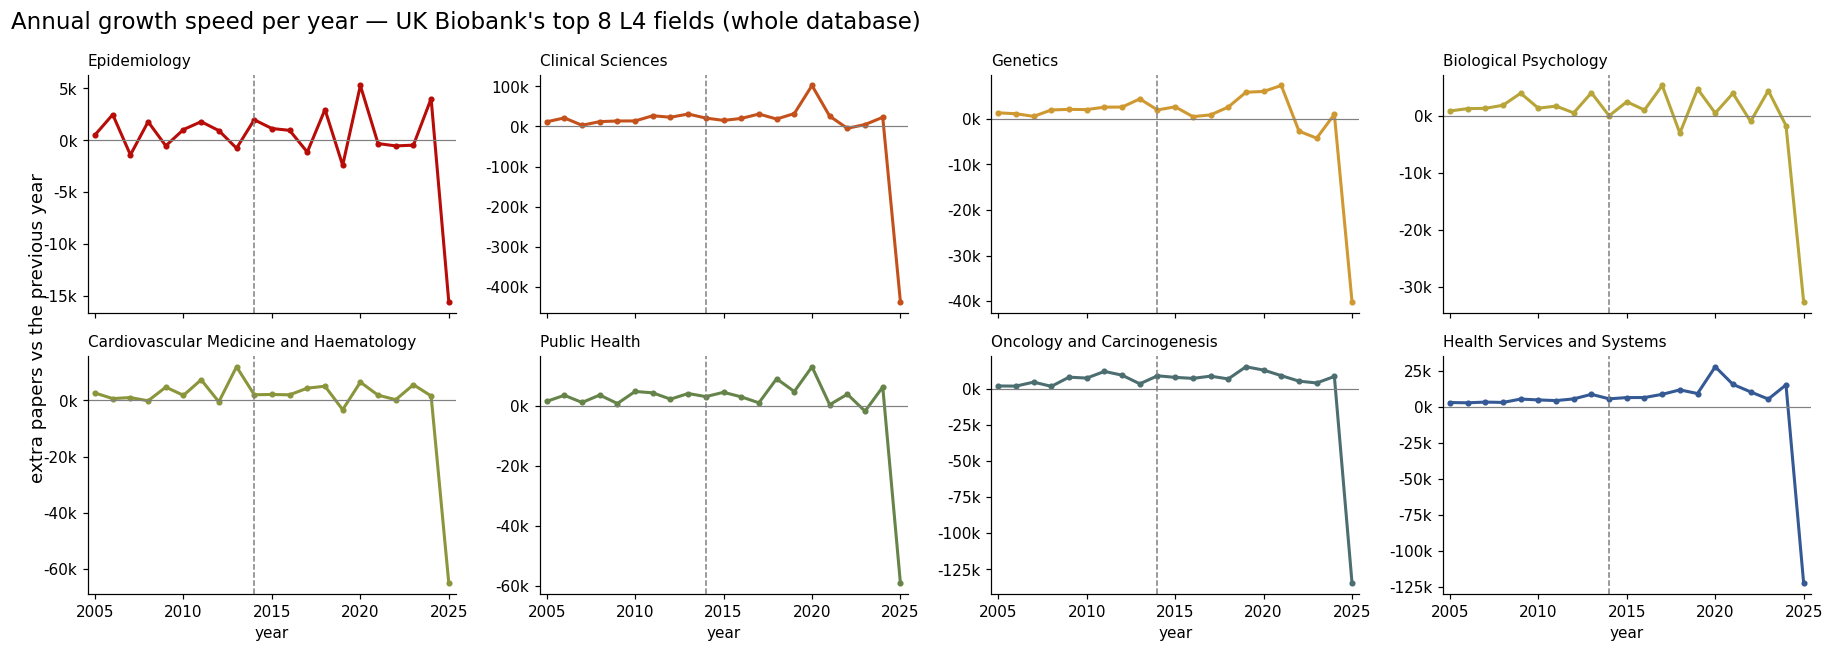

In [17]:
# =============================================================================
# CHART 3 — the growth SPEED of each field, year by year
# =============================================================================
# "Speed" = the annual increase: how many more papers a field gained versus the
# year before (the first difference of Chart 1's whole-database curve). We plot it
# ACROSS years, per field, rather than collapsing it to a single before/after
# number — so the change in pace is shown descriptively, not as a story about a
# cause. The dashed line at UKBB_YEAR is only a time reference; a rise to its
# right is a field-wide trend, and UK Biobank (single-digit % of any field) is far
# too small to have bent these curves.
speed_ts = whole_ts.diff()      # papers gained vs the previous year
kfmt = mticker.FuncFormatter(lambda x, _: f"{x / 1000:,.0f}k")

ncol = 4
nrow = int(np.ceil(TOP_N / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(4.2 * ncol, 3.0 * nrow), sharex=True)
axes = np.atleast_1d(axes).ravel()

for ax, lab in zip(axes, TOP_LABELS):
    s = speed_ts[lab].dropna()
    ax.plot(s.index, s.values, color=FIELD_COLORS[lab], lw=2, marker="o", ms=3)
    ax.axhline(0, color=STYLE["edgecolor"], lw=0.8)
    ax.axvline(UKBB_YEAR, color=STYLE["edgecolor"], ls="--", lw=1)
    ax.set_title(lab, fontsize=STYLE["annot_fs"] + 1, loc="left")
    ax.yaxis.set_major_formatter(kfmt)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(5))
    ax.margins(x=0.02)
for ax in axes[TOP_N:]:
    ax.set_visible(False)
for ax in axes[TOP_N - ncol:TOP_N]:
    ax.set_xlabel("year", fontsize=STYLE["tick_fs"])

fig.suptitle(f"Annual growth speed per year — UK Biobank's top {TOP_N} {LEVEL} "
             f"fields (whole database)", fontsize=STYLE["title_fs"], x=0.01, ha="left")
fig.supylabel("extra papers vs the previous year", fontsize=STYLE["label_fs"])
fig.tight_layout()
savefig(fig, "03_growth_speed")
plt.show()